In [257]:
import numpy as np
import matplotlib.pyplot as plt
import csv
import scipy.signal as scisig

In [258]:
2**14

16384

In [261]:
sigmax = 100
freqs = np.array([54000, 55000, 56000, 57000, 46000, 45000, 44000, 43000])
time = np.linspace(0, 0.001-0.001/16385, 16384)
sig_f = np.zeros(len(time))
for i in range(10000):
    sig = np.zeros(len(time))
    for f in freqs:
        sig += np.sin(2*np.pi*f*time+np.random.uniform(0, 2*np.pi))
    if np.max(sig) < sigmax:
        sigmax = np.max(abs(sig))
        sig_f = sig

3.996843708288847


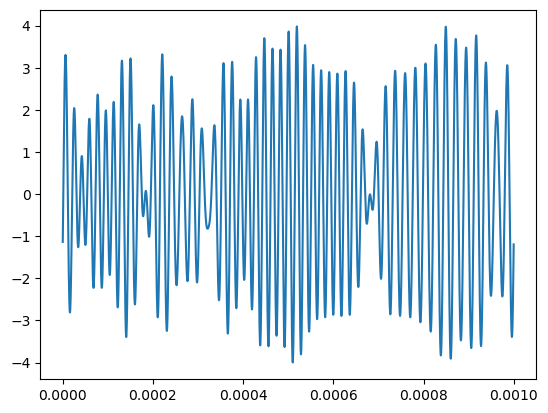

In [262]:
plt.plot(time, sig_f)
print(np.max(abs(sig_f)))

In [263]:
sig_ff = np.array([0])
for i in range(100):
    sig_ff = np.concatenate((sig_ff, sig_f))

In [264]:
PSD0 = scisig.welch(sig_f, fs = int(1/time[1]),nperseg = 16384)
PSD = scisig.welch(sig_ff, fs = int(1/time[1]),nperseg = 16384*100)
PSD2 = scisig.welch(np.round(sig_ff, 3), fs = int(1/time[1]),nperseg = 16384*100)
urand = np.random.uniform(-0.0005, 0.0005, len(sig_ff))
PSD3 = scisig.welch(np.round(sig_ff+urand, 3), fs = int(1/time[1]),nperseg = 16384*100)

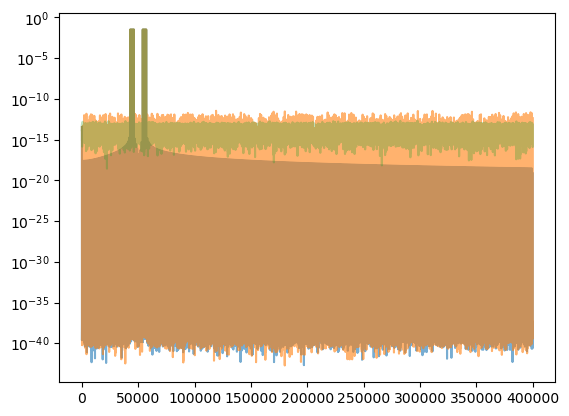

In [265]:
#plt.plot(PSD0[0][:200], PSD0[1][:200])
plt.plot(PSD[0][:40000], PSD[1][:40000], alpha = 0.6)
plt.plot(PSD2[0][:40000], PSD2[1][:40000], alpha =  0.6)
plt.plot(PSD3[0][:40000], PSD3[1][:40000], alpha = 0.3)
plt.yscale('log')

In [267]:
filename = 'C:\\Users\\yuhan\\nanospheres\\control\\Lorentz_force_fcomb2.csv'
header = [['RIGOL:CSV DATA FILE'],
['TYPE:Arb'],
['AMP:2Vpp'],
['DATA Number:16384'],
['MODE:Insert'],
['Sample Rate:16384000'],
['FileHead Length:15']]
spaces = [[''], [''], [''], [''], [''], [''], [''], ['']]
data = [[-i] for i in sig_f/4]
with open(filename, 'w', newline='') as file:
    writer = csv.writer(file)
    writer.writerows(header)
    writer.writerows(spaces)
    writer.writerows(data)

In [7]:
sig_ff = np.array([0])
for i in range(100):
    sig_ff = np.concatenate((sig_ff, sig_f))

In [246]:
sig1 = sig_ff - 1.01*sig_ff
sig2 = 1*sig_ff - 1.01*np.concatenate((sig_ff[1:], sig_ff[0:1]))

In [247]:
PSD1 = scisig.welch(sig1, fs = int(1/time[1]),nperseg = 16384*100)
PSD2 = scisig.welch(sig2, fs = int(1/time[1]),nperseg = 16384*100)

(1e-06, 0.3)

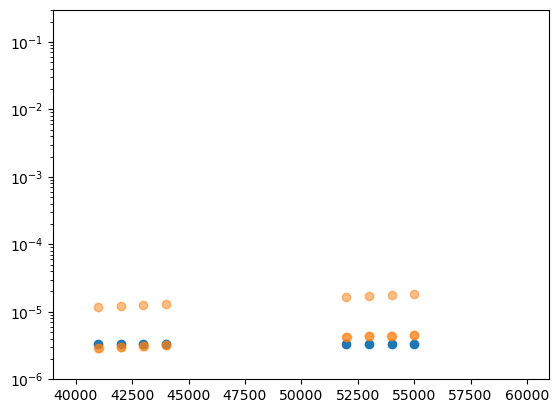

In [250]:
lb = 4000
ub = 6000
plt.plot(PSD1[0][lb:ub], PSD1[1][lb:ub], 'o')
plt.plot(PSD2[0][lb:ub], PSD2[1][lb:ub], 'o', alpha = 0.5)
plt.yscale('log')
plt.ylim(0.000001, 0.3)

In [251]:
1/1684*0.001

5.938242280285035e-07

In [256]:
0.25/360*0.001

6.944444444444445e-07